In [3]:
%pip install --upgrade pip setuptools wheel
%pip install "pandas>=3.0" numpy matplotlib
%pip install sqlalchemy psycopg2-binary
%pip install wrds --no-deps

  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
Using cached wheel-0.48.0-py3-none-any.whl (33 kB)
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting uninstall: setuptools
    Found existing installation: setuptools 83.0.0
    Uninstalling setuptools-83.0.0:
      Successfully uninstalled setuptools-83.0.0━━━━━━━━━━━━━━━━━━ 1/2 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [setuptools]2 [setuptools]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached psycopg2_binary-2.9.13-cp314-cp314-macosx_11_0_arm64.whl.metadata (4.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 3.8 MB/s  0:00:00 eta 0:00:01
Using cached psycopg2_

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("walmart.csv")
data.head()

,costat,curcd,datafmt,indfmt,consol,sic,datadate,gvkey,conm,tic,fyear,at,ceq,ceql,gdwl,intan,aqc,csho,prcc_f
0,A,USD,STD,INDL,C,5080,2019-05-31,1004,AAR CORP,AIR,2018,1517.2,905.9,905.9,116.2,145.6,2.3,34.788,30.09
1,A,USD,STD,INDL,C,5080,2020-05-31,1004,AAR CORP,AIR,2019,2079.0,902.6,902.6,115.7,125.8,0.0,35.097,20.17
2,A,USD,STD,INDL,C,5080,2021-05-31,1004,AAR CORP,AIR,2020,1539.7,974.4,974.4,119.3,148.8,0.0,35.375,41.75
3,A,USD,STD,INDL,C,5080,2022-05-31,1004,AAR CORP,AIR,2021,1573.9,1034.5,1034.5,116.4,141.9,0.0,35.391,48.22
4,A,USD,STD,INDL,C,5080,2023-05-31,1004,AAR CORP,AIR,2022,1833.1,1099.1,1099.1,175.8,279.1,103.3,34.916,50.11


In [12]:
data["sic"] = data["sic"].astype(str)

industry = data[data["sic"].str[:2] == "53"].copy()
industry["market_cap"] = industry["prcc_f"] * industry["csho"] #Market Cap = Share Price * Sharesutstanding

latest_year = industry[industry["tic"] == "WMT"]["fyear"].max()
print(latest_year)
latest = industry[industry["fyear"] == latest_year].copy()
latest = latest.dropna(subset=["market_cap"])
latest["market_cap"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)

2025


count        16.000000
mean     102399.026839
std      247419.035962
min        1956.640000
1%         2157.816394
25%        6482.803425
50%       11283.911140
75%       48332.264850
99%      869729.810026
max      949426.660000
Name: market_cap, dtype: float64

In [14]:
walmart = latest[latest["tic"] == "WMT"]
wmt_market_cap = walmart["market_cap"].iloc[0] #iloc takes the first value of the market cap column
print("Walmart's Market Capitalisation:", wmt_market_cap)

Walmart's Market Capitalisation: 949426.66


In [15]:
#find the difference in market caps
#for every company in 'latest', company market cap - walmart market cap
# abs makes the result positive
latest["difference"] = abs(
    latest["market_cap"] - wmt_market_cap
)
not_walmart=latest[latest["tic"] != "WMT"] #removes walmart
sorted_companies=not_walmart.sort_values("difference") #sorts company market cap difference in ascending order
peers = sorted_companies.head(5) #keeps first 5 companies (closest peers)
print(peers[["conm", "tic", "market_cap", "difference"]])


                             conm    tic     market_cap     difference
27032       COSTCO WHOLESALE CORP   COST  418114.326840  531312.333160
66761  WAL MART DE MEXICO S A B D  WMMVY   53868.692592  895557.967408
87903               DOLLARAMA INC  DLMAF   50045.955000  899380.705000
1825                  TARGET CORP    TGT   47761.034800  901665.625200
1948          DOLLAR GENERAL CORP     DG   31586.441460  917840.218540


['WMT', 'COST', 'WMMVY', 'DLMAF', 'TGT', 'DG']
[2021, 2022, 2023, 2024, 2025]
tic     COST     DG  DLMAF    TGT  WMMVY    WMT
fyear                                          
2021   0.087  0.131 -0.003  0.123  0.139  0.216
2022   0.089  0.108  0.001  0.142  0.168  0.198
2023   0.103  0.233  0.014  0.209  0.160  0.189
2024   0.060  0.474  0.031  0.233  0.243  0.116
2025   0.070  0.269  0.029  0.338  0.243  0.105


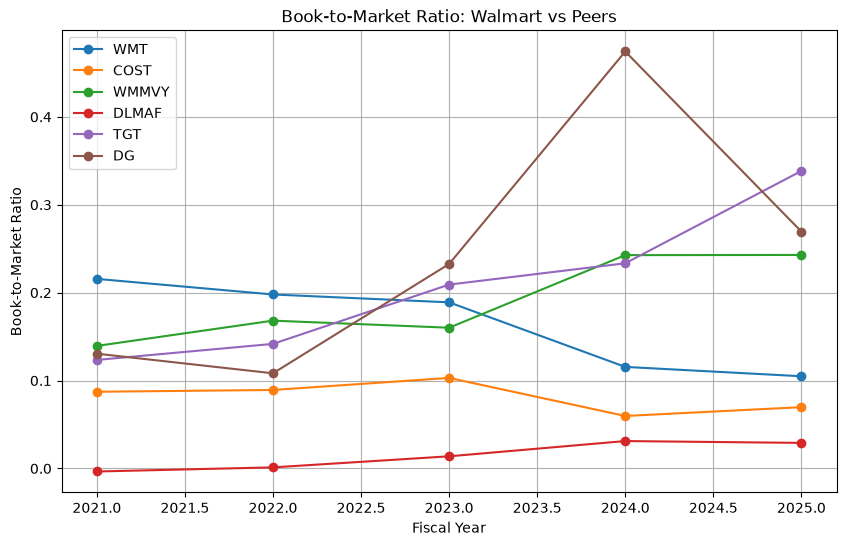

In [19]:
#calculate book-to-market=book value of equity(common equity)/market value of equity(market cap)
industry["book_to_market"] = (
    industry["ceq"] / industry["market_cap"]
)
companies = ["WMT"] + peers["tic"].tolist()
print(companies)
comparison = industry[industry["tic"].isin(companies)].copy()
years = list(range(int(latest_year) - 4, int(latest_year) + 1))

print(years)
comparison = comparison[comparison["fyear"].isin(years)].copy()

btm_table = comparison.pivot_table(
    index="fyear",
    columns="tic",
    values="book_to_market"
)

print(btm_table.round(3))

plt.figure(figsize=(10, 6))

for company in companies:
    company_data = comparison[comparison["tic"] == company]
    company_data = company_data.sort_values("fyear")

    plt.plot(
        company_data["fyear"],
        company_data["book_to_market"],
        marker="o",
        label=company
    )

plt.xlabel("Fiscal Year")
plt.ylabel("Book-to-Market Ratio")
plt.title("Book-to-Market Ratio: Walmart vs Peers")
plt.legend()
plt.grid()

plt.show()


In [21]:
btm_change = btm_table.iloc[-1] - btm_table.iloc[0]

print(btm_change.round(3)) #2025 B/M - 2021 B/M

comparison = industry[industry["tic"].isin(companies)].copy()

years = list(range(int(latest_year) - 4, int(latest_year) + 1))

comparison = comparison[
    comparison["fyear"].isin(years)
].copy()

btm_table = comparison.pivot_table(
    index="fyear",
    columns="tic",
    values="book_to_market"
)

print(btm_table.round(3))

btm_change = btm_table.iloc[-1] - btm_table.iloc[0]

print(btm_change.round(3))

tic
COST    -0.018
DG       0.139
DLMAF    0.033
TGT      0.215
WMMVY    0.103
WMT     -0.111
dtype: float64
tic     COST     DG  DLMAF    TGT  WMMVY    WMT
fyear                                          
2021   0.087  0.131 -0.003  0.123  0.139  0.216
2022   0.089  0.108  0.001  0.142  0.168  0.198
2023   0.103  0.233  0.014  0.209  0.160  0.189
2024   0.060  0.474  0.031  0.233  0.243  0.116
2025   0.070  0.269  0.029  0.338  0.243  0.105
tic
COST    -0.018
DG       0.139
DLMAF    0.033
TGT      0.215
WMMVY    0.103
WMT     -0.111
dtype: float64


### Book-to-Market Comparison

Walmart's book-to-market ratio fell from **0.216 in 2021** to **0.105 in 2025**, representing a decrease of **0.111** over the five-year period.

This contrasts with most of its selected peers, whose book-to-market ratios increased over the same period. **Costco** was the only other peer to experience a decline, although its decrease was much smaller at **0.018**.

By 2025, Walmart's book-to-market ratio of **0.105** was lower than those of **Dollar General, Target, and Wal-Mart de México**, but higher than **Costco and Dollarama**.